In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# EDA about churned clients
df = pd.read_csv("ecommerce_customer_analytics.csv")

In [4]:
df.columns

Index(['customer_id', 'age', 'gender', 'country', 'region', 'income_bracket',
       'signup_date', 'last_purchase_date', 'customer_lifetime_days',
       'days_since_last_purchase', 'total_orders', 'total_spent_usd',
       'avg_order_value_usd', 'preferred_category', 'preferred_payment_method',
       'device_type', 'loyalty_tier', 'discount_usage_rate', 'return_rate',
       'newsletter_subscribed', 'referral_source', 'avg_session_duration_min',
       'avg_pages_per_session', 'satisfaction_score', 'churn'],
      dtype='object')

In [5]:
df.head(3)

,customer_id,age,gender,country,region,income_bracket,signup_date,last_purchase_date,customer_lifetime_days,days_since_last_purchase,...,device_type,loyalty_tier,discount_usage_rate,return_rate,newsletter_subscribed,referral_source,avg_session_duration_min,avg_pages_per_session,satisfaction_score,churn
0,CUST-00001,35,Male,United States,North America,"$75,000–$99,999",2022-10-17,2024-11-13,759,48,...,Desktop,Platinum,0.229,0.084,False,Social Media,10.2,6.4,4,0
1,CUST-00002,58,Male,Germany,Europe,"$25,000–$49,999",2020-12-05,2024-04-24,1237,251,...,Mobile,Gold,0.349,0.019,True,Social Media,1.0,6.9,5,0
2,CUST-00003,43,Female,Australia,Asia-Pacific,"$75,000–$99,999",2019-05-27,2022-10-25,1248,798,...,Desktop,Platinum,0.186,0.117,True,Paid Ad,7.4,1.1,3,1


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 25 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   customer_id               1200 non-null   object 
 1   age                       1200 non-null   int64  
 2   gender                    1200 non-null   object 
 3   country                   1200 non-null   object 
 4   region                    1200 non-null   object 
 5   income_bracket            1200 non-null   object 
 6   signup_date               1200 non-null   object 
 7   last_purchase_date        1200 non-null   object 
 8   customer_lifetime_days    1200 non-null   int64  
 9   days_since_last_purchase  1200 non-null   int64  
 10  total_orders              1200 non-null   int64  
 11  total_spent_usd           1200 non-null   float64
 12  avg_order_value_usd       1200 non-null   float64
 13  preferred_category        1200 non-null   object 
 14  preferre

In [7]:
inactive = df[df['churn'] == 1]
active = df[df['churn'] == 0]

In [8]:
inactive.describe()

,age,customer_lifetime_days,days_since_last_purchase,total_orders,total_spent_usd,avg_order_value_usd,discount_usage_rate,return_rate,avg_session_duration_min,avg_pages_per_session,satisfaction_score,churn
count,808.000000,808.000000,808.000000,808.000000,808.000000,808.000000,808.000000,808.000000,808.000000,808.000000,808.000000,808.0
mean,36.700495,552.785891,867.800743,46.456683,4338.543441,79.888886,0.259467,0.137984,7.975495,5.345916,3.035891,1.0
std,11.678973,419.001563,428.353800,53.547168,7501.139488,46.749184,0.148522,0.106325,3.872391,2.387542,1.271145,0.0
min,18.000000,1.000000,198.000000,1.000000,7.290000,4.990000,0.014000,0.001000,1.000000,1.000000,1.000000,1.0
25%,28.000000,206.750000,508.750000,10.000000,581.372500,49.287500,0.145000,0.059000,5.100000,3.700000,2.000000,1.0
50%,36.000000,478.500000,765.000000,28.500000,1830.525000,71.445000,0.234000,0.109000,7.700000,5.300000,3.000000,1.0
75%,45.000000,840.250000,1135.250000,62.000000,4677.095000,96.685000,0.355500,0.187000,10.700000,6.925000,4.000000,1.0
max,73.000000,1797.000000,2152.000000,350.000000,66041.210000,315.250000,0.738000,0.544000,20.000000,12.900000,5.000000,1.0


In [9]:
# Total Revenue Lost
total_inactive = inactive['total_spent_usd'].sum()

# % Revenue Lost
Total = df['total_spent_usd'].sum()

print(f'{(total_inactive/Total)*100:.2f}% of revenue was lost')


55.12% of revenue was lost


In [10]:
#Historical customers lost

number_inactive_customer = inactive['customer_id'].count()
total_customer = df['customer_id'].count()

print(f'{(number_inactive_customer/total_customer)*100:.2f}% of lost customers')

67.33% of lost customers


In [11]:
#Historical Average Ticket (Churn x Active)

avg_spend_active = active['avg_order_value_usd'].mean()
avg_spend_inactive = inactive['avg_order_value_usd'].mean()

print(f'Average ticket of active customers ${avg_spend_active:.2f}')
print(f'Average ticket of inactive customers ${avg_spend_inactive:.2f}')

Average ticket of active customers $83.02
Average ticket of inactive customers $79.89


In [12]:
churn_per_tier = df.groupby('loyalty_tier').agg(
    total_clients = ('customer_id', 'count'),
    avg_churn = ('churn', 'mean'),
    lost_revenue = ('total_spent_usd', lambda x: x[df['churn'] == 1].sum())
).sort_values(by= ['lost_revenue'], ascending= False).reset_index()

display(churn_per_tier)

,loyalty_tier,total_clients,avg_churn,lost_revenue
0,Platinum,332,0.575301,2582490.35
1,Gold,345,0.626087,644710.17
2,Silver,345,0.707246,249835.19
3,Bronze,178,0.882022,28507.39


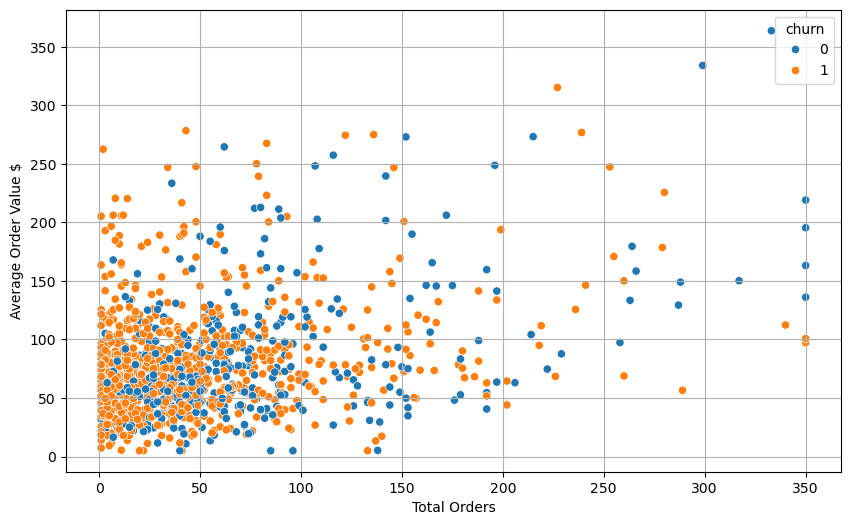

In [13]:
plt.figure(figsize=(10, 6))

sns.scatterplot(data = df,
                 x= 'total_orders',
                 y= 'avg_order_value_usd',
                 hue= 'churn'
)

plt.xlabel('Total Orders')
plt.ylabel('Average Order Value $')
plt.grid(True)

In [14]:
condictions = [(df['churn'] == 1),
               (df['churn'] == 0) & (df['days_since_last_purchase'] > 90) & (df['days_since_last_purchase'] < 180) & (df['satisfaction_score'] <= 2),
               (df['churn'] == 0) & (df['days_since_last_purchase'] > 120)]

category = ['churned','high risk', 'medium risk']

df['risk_level_churn'] = np.select(condictions, category, default = 'no risk')

In [15]:
# Analyzing revenue at risk by category

revenue_at_risk = df.groupby('risk_level_churn').agg(
    customer_number =('customer_id', 'count'),
    total_revenue_usd=('total_spent_usd', 'sum'),
    average_ticket_price=('avg_order_value_usd', 'mean')
).sort_values(by= ['total_revenue_usd'], ascending= False).reset_index()

display(revenue_at_risk)

,risk_level_churn,customer_number,total_revenue_usd,average_ticket_price
0,churned,808,3505543.10,79.888886
1,medium risk,231,1566180.10,80.959221
2,no risk,153,1215983.79,85.604706
3,high risk,8,72462.25,93.183750


Text(0, 0.5, 'Total Revenue $ (Million)')

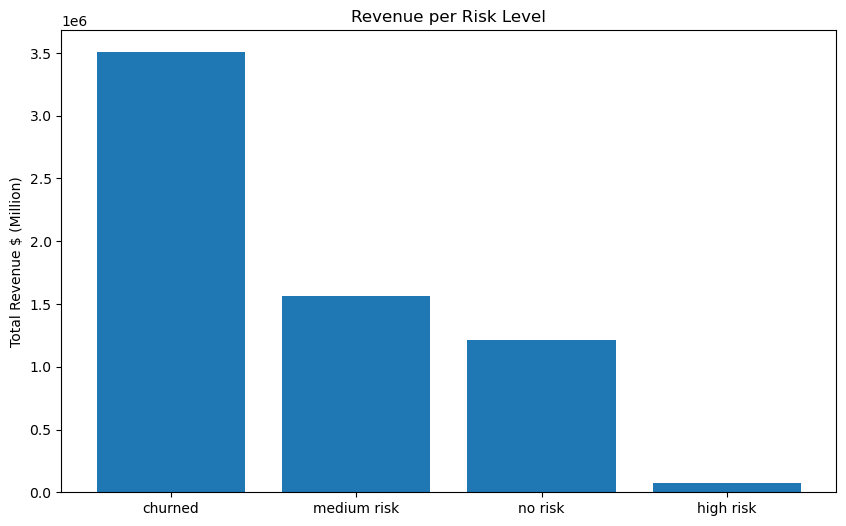

In [18]:
plt.figure(figsize=(10,6))
plt.bar(revenue_at_risk['risk_level_churn'],
        revenue_at_risk['total_revenue_usd'])

plt.title('Revenue per Risk Level')
plt.ylabel('Total Revenue $ (Million)')
